# QUEST 6

__Scatter Matrix__

In [125]:
from pandas.plotting import scatter_matrix
import pandas as pd
import sqlite3

In [126]:
database_path = "../data/checking-logs.sqlite"

In [127]:
try:
    connection = sqlite3.connect(database=database_path)
except Exception:
    print("The connection is failed :(")

## Operating the data

In [128]:
query = """
select * from test
where labname != 'project1'
"""
df = pd.io.sql.read_sql(query, connection, index_col="index")
display(df.head())

,uid,labname,first_commit_ts,first_view_ts
index,,,,
4,user_30,laba04,2020-04-18 13:36:53,2020-04-17 22:46:26
7,user_30,laba04s,2020-04-18 14:51:37,2020-04-17 22:46:26
8,user_14,laba04,2020-04-18 15:14:00,2020-04-18 10:53:52
11,user_14,laba04s,2020-04-18 22:30:30,2020-04-18 10:53:52
18,user_19,laba04,2020-04-20 19:05:01,2020-04-21 20:30:38


Таблица просмотров:

In [129]:
query = """
select uid, count(*) as pageviews
FROM pageviews
WHERE uid LIKE 'user_%'
GROUP BY uid
"""
df_views = pd.io.sql.read_sql(query, connection)
display(df_views.head())

,uid,pageviews
0,user_1,28
1,user_10,89
2,user_14,143
3,user_17,47
4,user_18,3


Таблица коммитов:

In [130]:
query = """
select uid, count(*) as num_commits from checker
where uid like 'user_%' and labname != 'project1'
group by uid
"""
df_commits = pd.io.sql.read_sql(query, connection)
display(df_commits.head())

,uid,num_commits
0,user_0,3
1,user_1,62
2,user_10,20
3,user_11,7
4,user_12,86


Дельта таблица (коммит - дедлайн):

In [131]:
query = """
select uid, CAST((julianday(t.first_commit_ts) - julianday(datetime(d.deadlines, 'unixepoch'))) * 24 as integer) as avg_diff
from test t
left join deadlines d ON t.labname=d.labs
where t.labname <> 'project1'
"""
df_delta = pd.io.sql.read_sql(query, connection)
display(df_delta.head())

,uid,avg_diff
0,user_30,-202
1,user_30,-201
2,user_14,-200
3,user_14,-193
4,user_19,-148


In [132]:
df_delta = df_delta.groupby(by="uid").mean().reset_index()
display(df_delta)

,uid,avg_diff
0,user_1,-64.400000
1,user_10,-74.800000
2,user_14,-159.000000
3,user_17,-61.600000
4,user_18,-5.666667
5,user_19,-98.750000
6,user_21,-95.500000
7,user_25,-92.600000
8,user_28,-86.400000
9,user_3,-105.400000


In [133]:
df_res = df_delta.merge(df_views, on="uid", how="inner")
df_res = df_res.merge(df_commits, on="uid", how="inner")
df_res.set_index("uid", inplace=True)
display(df_res)

,avg_diff,pageviews,num_commits
uid,,,
user_1,-64.400000,28,62
user_10,-74.800000,89,20
user_14,-159.000000,143,61
user_17,-61.600000,47,51
user_18,-5.666667,3,5
user_19,-98.750000,16,118
user_21,-95.500000,10,65
user_25,-92.600000,179,79
user_28,-86.400000,149,60


## Plotting the Scatter Matrix

In [134]:
display(df_res.corr())

,avg_diff,pageviews,num_commits
avg_diff,1.000000,-0.279736,-0.304931
pageviews,-0.279736,1.000000,-0.163348
num_commits,-0.304931,-0.163348,1.000000


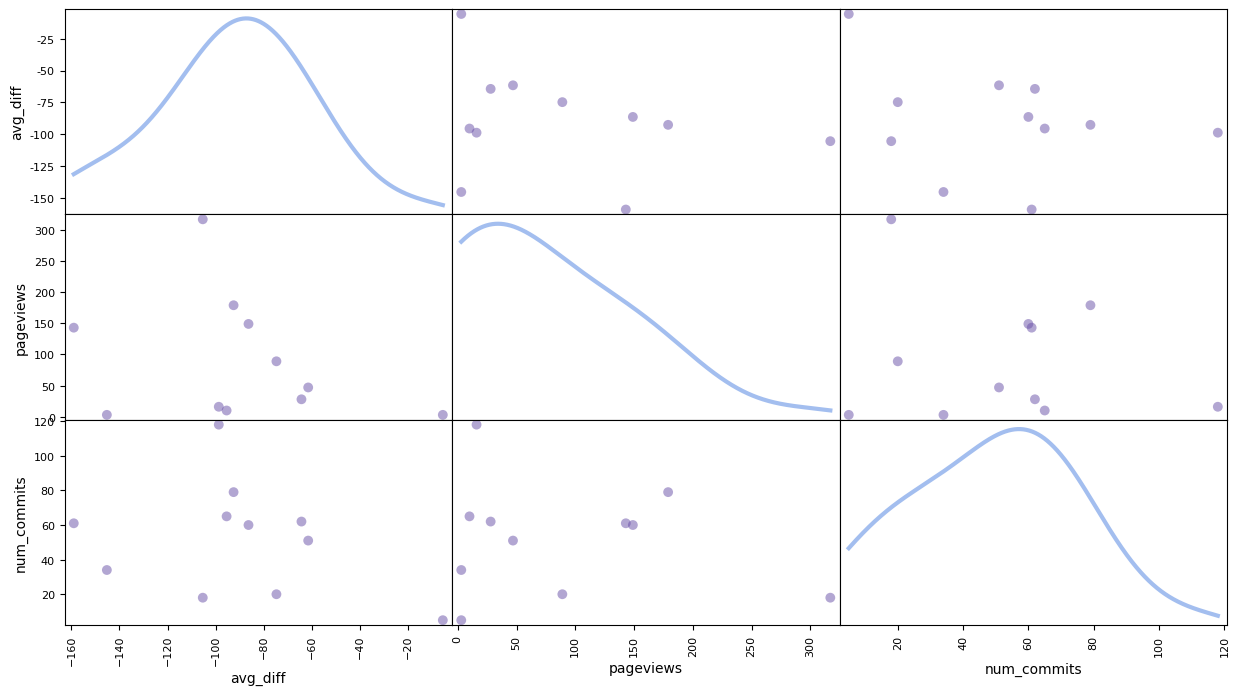

In [148]:
pic = scatter_matrix(frame=df_res, figsize=(15, 8), diagonal="kde", density_kwds={"color":"#a3beef", "linewidth":3},
                     s = 200, color="#674ea7")

In [136]:
connection.close()

## Questions

### 1) Can we say that if a user has a low number of pageviews then they likely have a low number of commits? - __NO__
Видно на секции num_commits = f(pageviews), что при pagevies < 50 (из 300), num_commits всреднем на уровне Q2 -> нет

### 2) Can we say that if a user has a low number of pageviews then they likely have a small average difference between the first commit and the lab deadline? - __NO__
Аналогично

### 3) Can we say that there are many users with a low number of commits and a few with a high number of commits? - __YES__
По ячейке A33 это видно

### 4) Can we say that there are many users with a small average difference and a few with a large average difference? - __NO__
Большая часть находится имеет средние значения, судя по ячейке A11